In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load dataset
df = pd.read_csv("/kaggle/input/customer-churn-dataset/customer_churn_data.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


In [12]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [14]:
df.drop(columns=['tenure'], inplace=True)

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [16]:
# Basic cleaning
df.drop_duplicates(inplace=True)

In [17]:
# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [21]:
X_train

,customerID,gender,SeniorCitizen,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2180,2180,0,1,0,1,0,2,1,1,1,1,1,1,0,1,0,110.24,4630.08,0
1827,1827,0,0,1,0,1,0,0,0,0,0,2,2,0,1,0,71.70,2222.70,1
3327,3327,1,0,1,1,0,0,0,0,2,2,0,2,0,0,3,58.51,3920.17,0
3367,3367,0,1,1,0,1,0,0,0,0,2,0,2,2,1,1,44.80,1523.20,0
2444,2444,0,0,1,1,2,2,1,1,1,1,1,1,1,1,3,99.04,297.12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,1684,1,0,1,0,1,0,0,2,0,0,0,0,2,0,0,49.77,3583.44,0
230,230,0,1,0,0,1,1,0,2,2,2,2,0,2,0,2,91.04,3004.32,0
4365,4365,1,0,1,1,2,2,1,1,1,1,1,1,0,0,1,44.45,444.50,0
3350,3350,0,1,1,0,1,2,1,1,1,1,1,1,1,0,1,66.75,734.25,0


In [22]:
y_train

2180    0
1827    1
3327    1
3367    1
2444    0
       ..
1684    1
230     0
4365    1
3350    1
2458    1
Name: Partner, Length: 4704, dtype: int64

In [23]:
X = df.drop("Partner", axis=1)
y = df["Partner"]

model.fit(X, y)

RandomForestClassifier(max_depth=12, min_samples_split=5, n_estimators=200,
                       random_state=42)

In [24]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(max_depth=12, min_samples_split=5, n_estimators=200,
                       random_state=42)

In [25]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.5034013605442177

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.46      0.47       577
           1       0.51      0.55      0.53       599

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.50      1176
weighted avg       0.50      0.50      0.50      1176


Confusion Matrix:
 [[264 313]
 [271 328]]


In [26]:
feature_importance = pd.Series(
    model.feature_importances_, 
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))


customerID          0.185171
MonthlyCharges      0.184766
TotalCharges        0.183691
PaymentMethod       0.053186
Contract            0.041741
MultipleLines       0.034467
TechSupport         0.027163
InternetService     0.025859
DeviceProtection    0.025660
StreamingTV         0.025184
dtype: float64


<Axes: ylabel='count'>

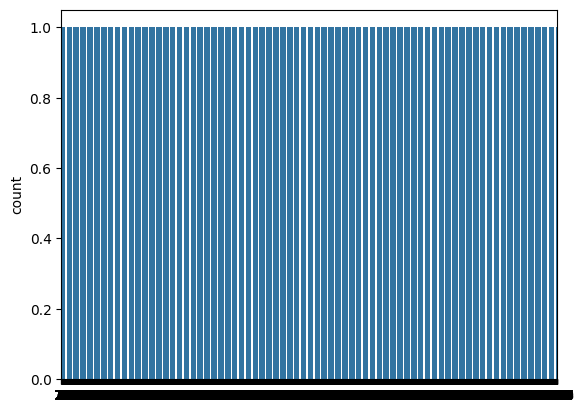

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(df['SeniorCitizen'])

<Axes: xlabel='InternetService', ylabel='Count'>

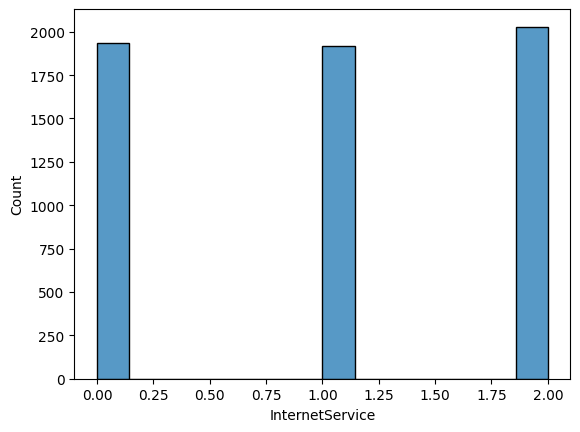

In [28]:
sns.histplot(df['InternetService'])

<Axes: ylabel='OnlineBackup'>

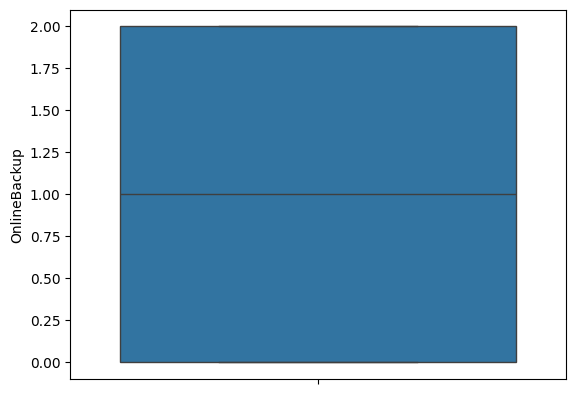

In [30]:
sns.boxplot(df['OnlineBackup'])

In [31]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))